# Imports

In [42]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline
import seaborn as sns
from typing import Optional
import pandas as pd
import numpy as np
from scipy import sparse
from anndata import AnnData
import scanpy as sc
import torch
from ciim.src.utils.util import bulkify_main
torch.set_float32_matmul_precision('medium')

import torch
from ciim.src.common import datasets_all


def plot_age_prediction(adata):
    from sklearn.metrics import r2_score
    from scipy.stats import spearmanr
    import seaborn as sns
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(6, 6))

    datasets = adata.obs['dataset'].unique()
    for dataset in datasets:
        subset = adata.obs[adata.obs['dataset'] == dataset]
        age = subset['age']
        pred = subset['predicted_age']

        r2 = r2_score(age, pred)
        rho, _ = spearmanr(age, pred)

        label = f"{dataset} (ρ={rho:.2f}, R²={r2:.2f})"
        sns.scatterplot(x=age, y=pred, s=10, ax=ax, label=label)

    # Plot diagonal reference line
    min_age = adata.obs['age'].min()
    max_age = adata.obs['age'].max()
    ax.plot([min_age, max_age], [min_age, max_age], 'r--', label="Identity")

    ax.set_xlabel("True Age")
    ax.set_ylabel("Predicted Age")
    ax.legend()
    ax.set_title("Age Prediction per Dataset")
    plt.tight_layout()
    plt.show()
def normalize(adata):
    adata.X = adata.X.todense().A if sparse.issparse(adata.X) else adata.X
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    return adata
def wrapper_umap(ad):
      sc.pp.neighbors(ad)
      sc.tl.umap(ad)

      sc.pl.umap(ad,
            color=['dataset', 'cell_type'],
            frameon=False,
            wspace=0.5)
def plot_history(model):
    import matplotlib.pyplot as plt
    import seaborn as sns
    import math

    df = model.epoch_history
    metric_cols = [col for col in df.columns if col not in ['epoch', 'mode']]
    n_metrics = len(metric_cols)

    n_rows = 2
    n_cols = math.ceil(n_metrics / n_rows)

    fig, axes = plt.subplots(n_rows, n_cols, sharex=True, figsize=(3 * n_cols, 2.5 * n_rows))
    axes = axes.flatten()

    train_df = df[df['mode'] == 'train']
    valid_df = df[df['mode'] == 'valid']

    for i, col in enumerate(metric_cols):
        ax = axes[i]
        ax.plot(train_df['epoch'].values, train_df[col].values, label='train')
        if len(valid_df) > 0:
            ax.plot(valid_df['epoch'].values, valid_df[col].values, label='valid')
        ax.set_title(col)

    # Hide unused subplots if any
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=2)
    plt.tight_layout(rect=[0, 0.05, 1, 1])

In [2]:
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from ciim.src.clock.helper import align_feature_space

class age_predictor:
    def __init__(self):
        self.reg = Ridge(alpha=1.0)
    def format_data(self, adata: AnnData):
        X = adata.X
        y = adata.obs["age"].values.astype(np.float32)
        group = adata.obs["donor_age"].values
        batch = adata.obs["dataset"].values
        return X, y, group, batch
    def train(self, adata):
        X, y, _, _ = self.format_data(adata)
        self.features = adata.var_names
        self.reg.fit(X, y)
    def predict(self, adata):
        adata = align_feature_space(adata, self.features)
        X, y, group, batch = self.format_data(adata)
        y_pred = self.reg.predict(X)
        self.evaluate(y_pred, y, group, batch)

    def train_cv(self, adata):
        X, y, group, batch = self.format_data(adata)
        cv = KFold(n_splits=5, shuffle=True, random_state=0)

        y_pred_store = []
        y_true_store = []
        group_store = []
        batch_store = []

        for train_idx, test_idx in cv.split(X):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]
            group_test = group[test_idx]
            batch_test = batch[test_idx]

            # Standardize
            # X_train = scaler.fit_transform(X_train)
            # X_test = scaler.transform(X_test)

            self.reg.fit(X_train, y_train)
            y_pred = self.reg.predict(X_test)

            y_pred_store.append(y_pred)
            y_true_store.append(y_test)
            group_store.append(group_test)
            batch_store.append(batch_test)

        # Concatenate results
        y_pred = np.concatenate(y_pred_store)
        y_test = np.concatenate(y_true_store)
        group_all = np.concatenate(group_store)
        batch_all = np.concatenate(batch_store)
        self.evaluate(y_pred, y_test, group_all, batch_all)
    def evaluate(self, y_pred, y_test, group_all, batch_all):
        # Aggregate by group and batch
        df = pd.DataFrame({
            "y_pred": y_pred,
            "y_true": y_test,
            "group": group_all,
            "batch": batch_all
        })
        df['group'] = df['group'].astype(str)
        df['batch'] = df['batch'].astype(str)
        df_grouped = df.groupby(["group", "batch"], as_index=False).median()

        # Compute metrics
        rho, _ = spearmanr(df_grouped["y_true"], df_grouped["y_pred"])
        r2 = r2_score(df_grouped["y_true"], df_grouped["y_pred"])

        print(f"Spearman correlation (per donor): {rho:.2f}, R² (per donor): {r2:.2f}")
    
        # Plot prediction
        plt.figure(figsize=(4, 4))
        sns.scatterplot(data=df_grouped, x="y_true", y="y_pred", hue="batch", alpha=0.7)
        min_val = min(df_grouped["y_true"].min(), df_grouped["y_pred"].min())
        max_val = max(df_grouped["y_true"].max(), df_grouped["y_pred"].max())
        plt.plot([min_val, max_val], [min_val, max_val], "r--")
        plt.xlabel("True median age (per donor)")
        plt.ylabel("Predicted median age (per donor)")
        # plt.title("Ridge regression on latent space")
        plt.legend(loc=(1, .8), frameon=False)
        # plt.tight_layout()

# EXA

In [26]:
from ciim.src.clock.NN.helper import format_data, train_datasets, data_type, cell_type, test_datasets
adata_train = format_data(train_datasets, cell_type, data_type)

In [27]:
adata_train

AnnData object with n_obs × n_vars = 7457 × 9674
    obs: 'sum_by', 'orig.ident', 'Major_CT', 'age', 'donor_id', 'sex', 'dataset', 'donor_age', 'cell_type', 'cell_count', 'disease'

In [28]:
adata_test = format_data(test_datasets, cell_type, data_type)
adata_test = align_feature_space(adata_test, adata_train.var_names)

In [29]:
if data_type=='sc':
    adata_train_bulk = bulkify_main(adata_train, covariates=['cell_type', 'donor_id', 'age'])
    adata_test_bulk = bulkify_main(adata_test, covariates=['cell_type', 'donor_id', 'age'])

    adata_train_bulk = normalize(adata_train_bulk)
    adata_test_bulk = normalize(adata_test_bulk)
else:
    adata_train_bulk = adata_train
    adata_test_bulk = adata_test

Spearman correlation (per donor): 0.80, R² (per donor): 0.33


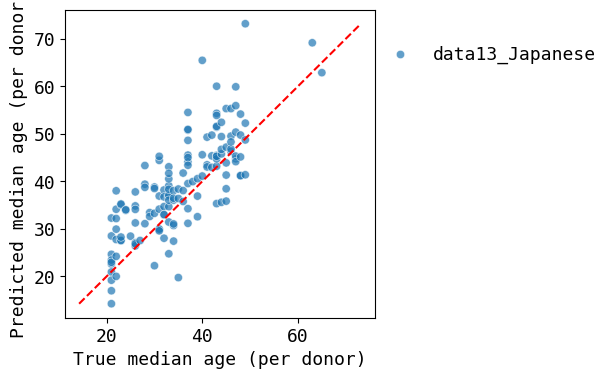

In [30]:
for cell_type in ['CD8T']:
    adata_train_bulk_t = adata_train_bulk[adata_train_bulk.obs['cell_type'] == cell_type].copy()
    adata_test_bulk_t = adata_test_bulk[adata_test_bulk.obs['cell_type'] == cell_type].copy()
    obj = age_predictor()
    obj.train(adata_train_bulk_t)
    obj.predict(adata_test_bulk_t)

In [43]:
# - original data embedding
adata_raw = adata_train.copy()
if data_type=='sc':
    sc.pp.normalize_total(adata_raw)
    sc.pp.log1p(adata_raw)
# sc.pp.highly_variable_genes(adata_raw, n_top_genes=2000, subset=True)
sc.pp.pca(adata_raw)
wrapper_umap(adata_raw)

KeyboardInterrupt: 

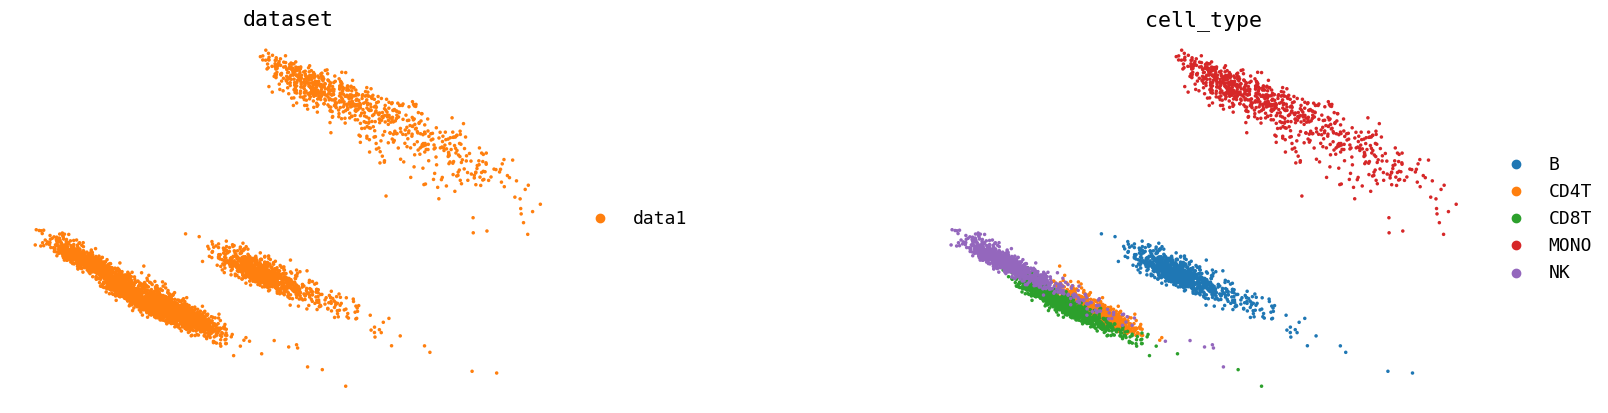

In [35]:
sc.pl.pca(adata_raw[adata_raw.obs['dataset'] == 'data1'],
            color=['dataset', 'cell_type'],
            frameon=False,
            wspace=0.5)

In [33]:
aaa

NameError: name 'aaa' is not defined

# Train

In [ ]:
# run ../scripts/run_train_nn.sh

python: can't open file '/home/jnourisa/projs/ongoing/ciim/notebooks/src/clock/NN/script_train.py': [Errno 2] No such file or directory


-TODO: 1. train with the original version. 2. reduce the epock, 3. make it 'nb'. 4. train with larger datasets 

In [38]:
import cpa
from ciim.src.common import save_dir
from ciim.src.clock.NN.helper import save_path_train, save_path_test, wrapper_setup_data, cell_type, data_type, batch_key
# save_path_train=f'{save_dir}/NN/try1' # trained with cleaned cpa, zinb, ['SLE_European', 'data12', 'data13_Korean']

model = cpa.CPA.load(dir_path=save_path_train)

INFO     File /vol/projects/jnourisa//output//NN/bulk_train/model.pt already downloaded                            


[rank: 0] Global seed set to 6977


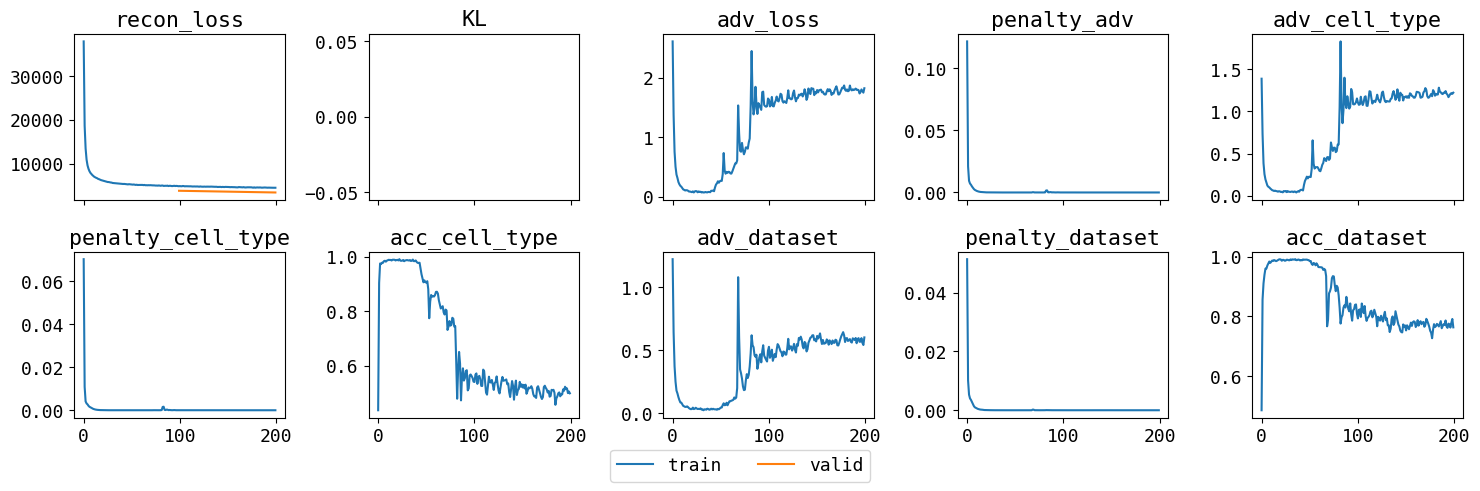

In [39]:
plot_history(model)

# Evaluate on train data

In [40]:
adata = adata_train.copy()
wrapper_setup_data(adata, data_type=data_type, batch_key=batch_key, cell_type=cell_type)
latent_dict = model.get_latent_representation(adata=adata)
adata_corrected = latent_dict['latent_corrected']

INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


100%|██████████| 234/234 [00:03<00:00, 72.27it/s] 


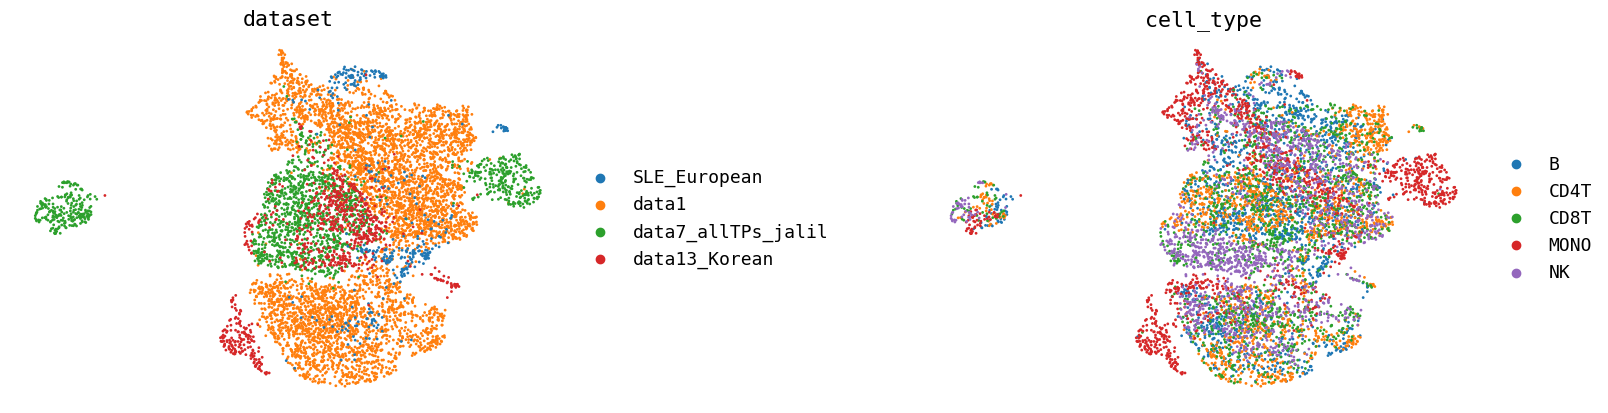

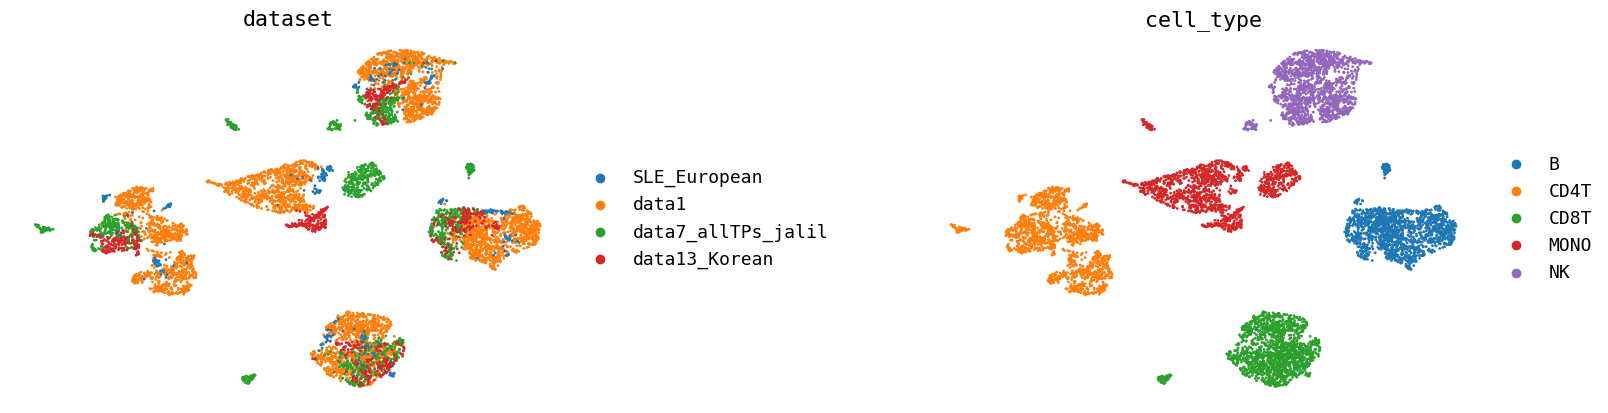

In [46]:
wrapper_umap(latent_dict['latent_basal'])
wrapper_umap(latent_dict['latent_corrected'])

Spearman correlation (per donor): 0.76, R² (per donor): 0.58


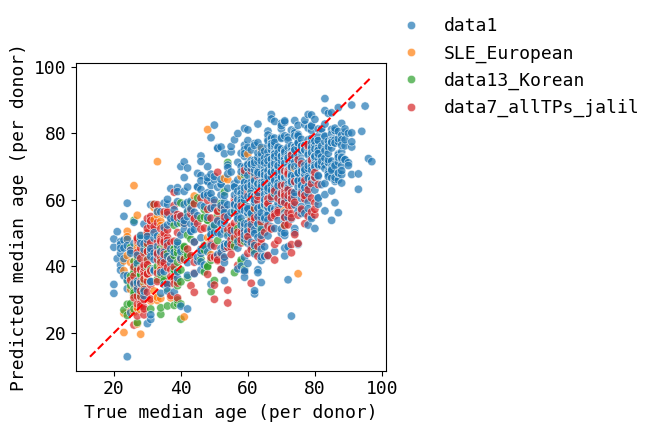

In [47]:
if data_type == 'sc':
    adata_corrected_bulk = bulkify_main(adata_corrected, covariates=['cell_type', 'donor_id', 'age'])
else:
    adata_corrected_bulk = adata_corrected
for cell_type in ['CD8T']:
    adata_corrected_bulk_t = adata_corrected_bulk[adata_corrected_bulk.obs['cell_type'] == cell_type].copy()

    obj = age_predictor()
    obj.train_cv(adata_corrected_bulk_t)

# Evaluate on test data

In [48]:
model_test = cpa.CPA.load(dir_path=save_path_test)

INFO     File /vol/projects/jnourisa//output//NN/bulk_test/model.pt already downloaded                             


[rank: 0] Global seed set to 6977


In [49]:
model_test.covars_encoder

{'cell_type': {'B': 0, 'CD4T': 1, 'CD8T': 2, 'MONO': 3, 'NK': 4},
 'dataset': {'SLE_European': 0,
  'data1': 1,
  'data13_Korean': 2,
  'data7_allTPs_jalil': 3,
  'data13_Japanese': 4}}

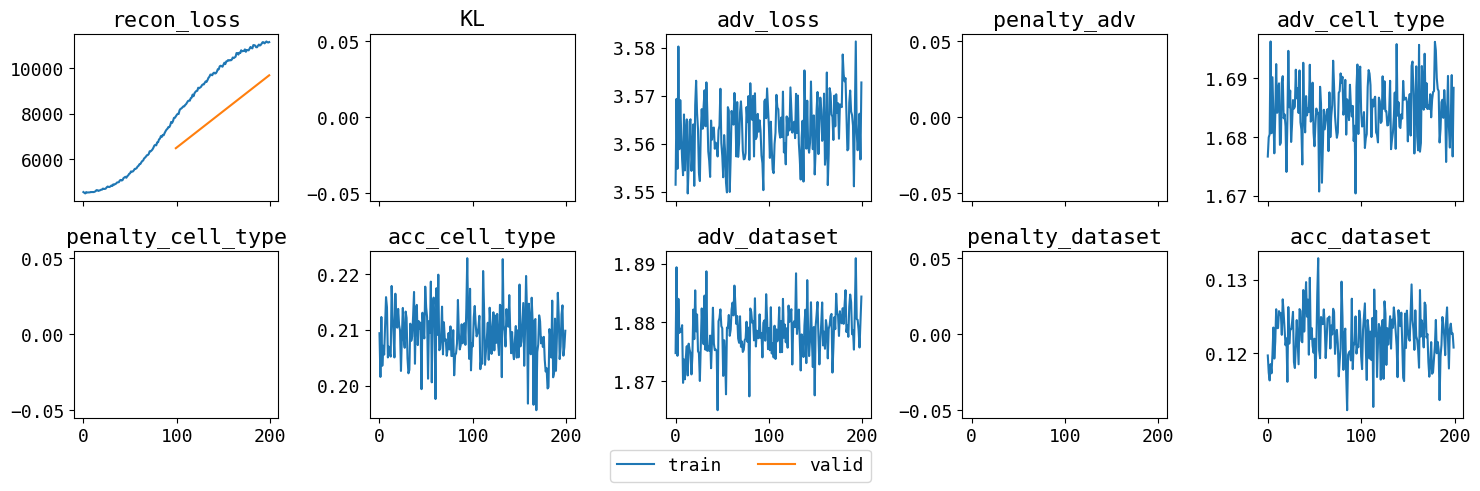

In [50]:
plot_history(model_test)

In [51]:
import anndata as ad
adata_all = ad.concat([adata_train, adata_test], axis=0)
wrapper_setup_data(adata_all, data_type=data_type, batch_key=batch_key, cell_type=cell_type)
latent_dict = model_test.get_latent_representation(adata=adata_all, extend_categories=True)
adata_corrected = latent_dict['latent_corrected']

100%|██████████| 256/256 [00:01<00:00, 213.76it/s]


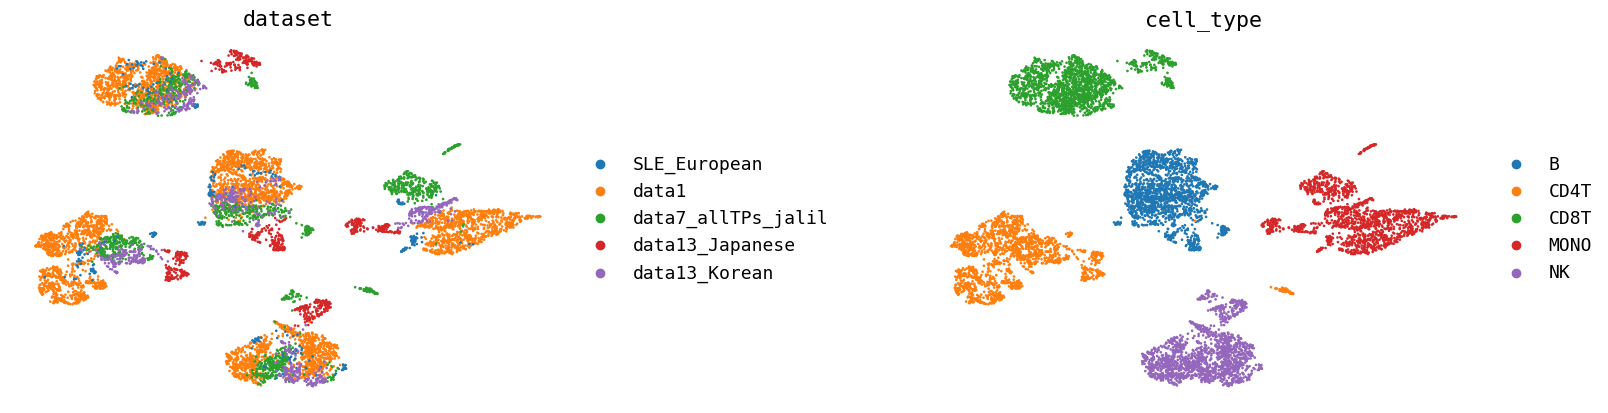

In [52]:
wrapper_umap(adata_corrected)

Spearman correlation (per donor): 0.58, R² (per donor): -0.25


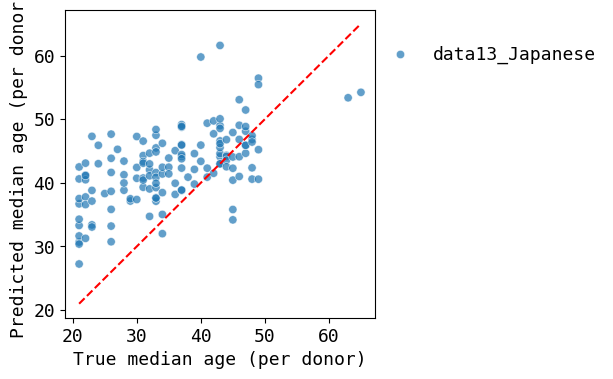

In [55]:
if data_type == 'sc':
    adata_corrected_bulk = bulkify_main(adata_corrected, covariates=['cell_type', 'donor_id', 'age'])
else:
    adata_corrected_bulk = adata_corrected

adata_corrected_bulk = adata_corrected_bulk[adata_corrected_bulk.obs['cell_type'] == 'CD8T'].copy()

adata_corrected_train = adata_corrected_bulk[adata_corrected_bulk.obs['dataset'].isin(train_datasets)].copy()
adata_corrected_test = adata_corrected_bulk[adata_corrected_bulk.obs['dataset'].isin(test_datasets)].copy()

obj = age_predictor()
obj.train(adata_corrected_train)
obj.predict(adata_corrected_test)